# Online Retail Data Analysis

## 1. Dataset Overview

This section provides an initial overview of the dataset, including its dimensions, columns, data types, and sample records.

In [2]:
import pandas as pd

df = pd.read_csv("data/OnlineRetail.csv", encoding = "latin1")

In [3]:
df.shape

(541909, 8)

In [4]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## 2. Dataset Dimensions

We examine the number of unique invoices, products, customers, and countries represented in the dataset.

In [7]:
df["InvoiceNo"].nunique()

25900

In [8]:
df["StockCode"].nunique()

4070

In [9]:
df["CustomerID"].nunique()

4372

In [10]:
df["Country"].nunique()

38

## 3. Transaction Structure

We investigate how products and customers are represented within individual invoices and examine the structure of transactions.

- How many Products can an Invoice have?

In [11]:
df.groupby("InvoiceNo")["StockCode"].nunique().max()

np.int64(1110)

In [12]:
df.groupby("InvoiceNo")["StockCode"].nunique().idxmax()

'573585'

In [13]:
df[df["InvoiceNo"] == "573585"]["StockCode"].duplicated().sum()

np.int64(4)

In [14]:
df.loc[~df["InvoiceNo"].str.isnumeric(), "InvoiceNo"].nunique()

3839

- Can an invoice be associated with multiple customers?

In [15]:
df[df["InvoiceNo"] == "536365"]["CustomerID"].nunique()

1

In [16]:
df.groupby("InvoiceNo")["CustomerID"].nunique().max()

np.int64(1)

## 4. Missing Values

In [17]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [18]:
df.isna().sum() / df.shape[0] * 100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

24.92% of the dataset would be lost if we removed rows with missing CustomerID

In [19]:
df[df["CustomerID"].isna()]["InvoiceNo"]

622       536414
1443      536544
1444      536544
1445      536544
1446      536544
           ...  
541536    581498
541537    581498
541538    581498
541539    581498
541540    581498
Name: InvoiceNo, Length: 135080, dtype: object

- Are missing CustomerID associated with specified products?

In [20]:
df[df["CustomerID"].isna()]["InvoiceNo"].str.startswith("C").sum()

np.int64(383)

Only a small number of records with missing CustomerID have an InvoiceNo starting with "C", suggesting that missing CustomerIDs are not primarily associated with these invoices.

- Are missing descriptions associated with specific products?

In [21]:
df[df["Description"].isna()]["StockCode"].nunique()

960

There are 1,454 rows with missing descriptions, corresponding to 960 unique products.

- Do the same StockCodes have descriptions in other transactions?

In [22]:
description_counts = df.groupby("StockCode")["Description"].count()

missing_codes = df[df["Description"].isna()]["StockCode"]

description_counts[
    missing_codes.isin(description_counts.index)
    &
    (description_counts > 0)
]

description_counts.nunique()

617

617 out of 960 products with missing descriptions have a non-missing description in other transactions.

- Does each StockCode have a consistent Description?

In [23]:
df.groupby("StockCode")["Description"].nunique()

StockCode
10002           1
10080           2
10120           1
10123C          1
10123G          0
               ..
gift_0001_20    2
gift_0001_30    1
gift_0001_40    1
gift_0001_50    1
m               1
Name: Description, Length: 4070, dtype: int64

- Do products have multiple different descriptions?

In [24]:
df.groupby("StockCode")["Description"].nunique().max()

np.int64(8)

The same StockCode can have multiple different descriptions, so missing descriptions cannot be reliably filled using StockCode alone.

## 5. Data Cleaning

- Are there duplicate rows in the dataset?

In [25]:
df.duplicated().sum()

np.int64(5268)

- What percentage of the dataset consists of duplicate rows?

In [26]:
df.duplicated().sum() / df.shape[0] * 100

np.float64(0.9721189350979592)

- What do duplicated rows look like?

In [27]:
df[df.duplicated()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom


The dataset contains 5,268 completely duplicated rows, representing about 0.97% of all rows.
Since these rows contain exactly the same information as previous records, they can be removed without losing unique information.

In [28]:
df.shape

(541909, 8)

In [29]:
df = df.drop_duplicates().copy()

In [30]:
df.shape

(536641, 8)

## 6. Data Types & Invalid Values

- What are the current data types of the columns?

In [31]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

#### Observations

Most columns have appropriate data types for analysis.

- `InvoiceDate` is stored as `object` and should be converted to `datetime`.
- `CustomerID` is stored as `float64` because it contains missing values.
- `InvoiceNo` and `StockCode` are kept as `object` because they are identifiers/codes and may contain non-numeric characters.

- Can we convert InvoiceDate to datetime safely?

In [32]:
pd.to_datetime(df["InvoiceDate"], errors="coerce").isna().sum()

np.int64(0)

In [33]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [34]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

`InvoiceDate` was successfully converted to datetime, with no invalid dates found.

- Are there any negative quantities?

In [35]:
df["Quantity"].min()

np.int64(-80995)

- How many transactions have negative quantities?

In [36]:
df[df["Quantity"] < 0].shape[0]

10587

- Are negative quantities associated with cancelled invoices?

In [37]:
df[(df["Quantity"] < 0) & (df["InvoiceNo"].str.startswith("C"))].shape[0]

9251

In [38]:
df[(df["Quantity"] < 0) & (df["InvoiceNo"].str.startswith("C"))].shape[0] / df[df["Quantity"] < 0].shape[0] * 100

87.38074997638613

most negative quantites (87.38%) are assosiated with cancelled transactios. But not all of them!

- What are the InvoiceNo patterns among negative-quantity transactions that do not start with "C"?

In [39]:
df[(df["Quantity"] < 0) &
   (~df["InvoiceNo"].str.startswith("C"))]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535333,581210,23395,check,-26,2011-12-07 18:36:00,0.0,NaN,United Kingdom
535335,581212,22578,lost,-1050,2011-12-07 18:38:00,0.0,NaN,United Kingdom
535336,581213,22576,check,-30,2011-12-07 18:38:00,0.0,NaN,United Kingdom
536908,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,NaN,United Kingdom


- It seems like negative-quantity transactions that don't start with "C" have 0.0 UnitPrice. Let's check:

In [40]:
df[(df["Quantity"] < 0) &
   (~df["InvoiceNo"].str.startswith("C"))]["UnitPrice"].max()

np.float64(0.0)

In [41]:
df[(df["Quantity"] < 0) &
   (~df["InvoiceNo"].str.startswith("C"))]["UnitPrice"].min()

np.float64(0.0)

- Do negative-quantity transactions have missing CustomerIDs?

In [42]:
df[(df["Quantity"] < 0) & (df["CustomerID"].isna())].shape[0]

1715

#### Result:

There are 10,587 transactions with negative quantities.

Most of them (9,251) have an InvoiceNo starting with "C", which is consistent with cancelled transactions.

The remaining 1,336 negative-quantity transactions do not have a "C" InvoiceNo. All of these transactions have a UnitPrice of 0. Their descriptions commonly refer to damages, disposal, adjustments, or incorrect entries.

We also found that 1,715 negative-quantity transactions have a missing CustomerID. Therefore, missing CustomerID is not exclusive to negative-quantity transactions.

Therefore, negative quantities should not be removed solely based on their sign. They represent different types of non-standard transactions that need to be considered separately from regular sales.

- Are there negative unit prices?

In [43]:
df["UnitPrice"].min()

np.float64(-11062.06)

- What do transactions with negative unit prices look like?

In [44]:
df[df["UnitPrice"] < 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


#### Result:

Only two transactions have a negative UnitPrice. Both are labeled "Adjust bad debt", indicating that these records are accounting adjustments rather than regular sales transactions.

- How many transactions have a zero UnitPrice?

In [45]:
df[df["UnitPrice"] == 0].shape[0]

2510

- Among zero-price transactions, how many have negative quantities?

In [46]:
df[(df["UnitPrice"] == 0) & (df["Quantity"] < 0)].shape[0]

1336

- What do zero-price transactions with non-negative quantities represent?

In [47]:
df[(df["UnitPrice"] == 0) & (df["Quantity"] >= 0)]["Description"].value_counts().head(20)

Description
check                              39
found                              25
adjustment                         14
FRENCH BLUE METAL DOOR SIGN 1       9
FRENCH BLUE METAL DOOR SIGN 8       8
amazon                              8
Found                               8
FRENCH BLUE METAL DOOR SIGN 3       7
RECIPE BOX PANTRY YELLOW DESIGN     7
OWL DOORSTOP                        7
FRENCH BLUE METAL DOOR SIGN 4       7
Amazon                              7
FRENCH BLUE METAL DOOR SIGN No      7
RED KITCHEN SCALES                  6
?                                   6
FRENCH BLUE METAL DOOR SIGN 6       6
FRENCH BLUE METAL DOOR SIGN 5       6
FRENCH BLUE METAL DOOR SIGN 7       6
Manual                              6
FRENCH BLUE METAL DOOR SIGN 2       5
Name: count, dtype: int64

In [48]:
df[(df["UnitPrice"] == 0) & (df["Quantity"] >= 0)]["StockCode"].nunique()

681

- Do products with a zero UnitPrice also appear with non-zero prices?

In [49]:
df[df["StockCode"] == "10002"]["UnitPrice"].unique()

array([0.85, 1.66, 1.63, 0.  ])

#### Result:

For example, StockCode 10002 appears with both zero and non-zero prices. Therefore, a zero UnitPrice does not necessarily indicate an invalid product or incorrect data.

- How many zero-price products also have non-zero prices?

In [50]:
zero_prices = df[df["UnitPrice"] == 0].groupby("StockCode")["UnitPrice"].nunique()
non_zero_prices = df[df["UnitPrice"] != 0].groupby("StockCode")["UnitPrice"].nunique()

len(zero_prices.index.intersection(non_zero_prices.index))

1287

#### Result:

Among the products with zero UnitPrice, 1,287 also appear in transactions with non-zero prices.

This shows that a zero UnitPrice does not necessarily indicate an invalid product or incorrect data. Some products have been recorded with both zero and non-zero prices.

- What proportion of transactions have a zero UnitPrice?

In [51]:
df[df["UnitPrice"] == 0].shape[0] / df.shape[0] * 100

0.46772423277386554

#### Result:

There are 2,510 transactions with a UnitPrice of 0, representing approximately 0.47% of the dataset.

Some of these transactions are associated with negative quantities and adjustments, while others have non-negative quantities.

We also found that many StockCodes with zero-price transactions appear in other transactions with non-zero prices. Therefore, a zero UnitPrice does not necessarily indicate invalid data.

For now, zero-price transactions will not be removed automatically. Their treatment will depend on the type of analysis being performed.

## 7. Exploratory Data Analysis (EDA)

### 7.1 Time Period

- What is the time period covered by the dataset?

In [52]:
df["InvoiceDate"].min()

Timestamp('2010-12-01 08:26:00')

In [53]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

#### Result:

The dataset contains transactions from December 1, 2010 to December 9, 2011, covering approximately one year of sales activity.

- How many transactions occurred in each month?

In [54]:
df.groupby(df["InvoiceDate"].dt.month).size()

InvoiceDate
1     34900
2     27479
3     36439
4     29701
5     36782
6     36609
7     39267
8     35064
9     49861
10    59969
11    83343
12    67227
dtype: int64

- What is the revenue generated by each transaction?

In [55]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [56]:
df["Revenue"].min()

np.float64(-168469.6)

In [57]:
df["Revenue"].max()

np.float64(168469.6)

In [58]:
df["Revenue"].head(10)

0    15.30
1    20.34
2    22.00
3    20.34
4    20.34
5    15.30
6    25.50
7    11.10
8    11.10
9    54.08
Name: Revenue, dtype: float64

- How does revenue changes across months?

In [59]:
df.groupby(df["InvoiceDate"].dt.month)["Revenue"].sum()

InvoiceDate
1      558448.560
2      497026.410
3      682013.980
4      492367.841
5      722094.100
6      689977.230
7      680156.991
8      681386.460
9     1017596.682
10    1069368.230
11    1456145.800
12    1179424.670
Name: Revenue, dtype: float64

- What is the average revenue per transaction in each month?

In [60]:
df.groupby(df["InvoiceDate"].dt.month)["Revenue"].mean()

InvoiceDate
1     16.001391
2     18.087500
3     18.716594
4     16.577484
5     19.631725
6     18.847202
7     17.321338
8     19.432651
9     20.408670
10    17.832017
11    17.471723
12    17.543913
Name: Revenue, dtype: float64

#### Result:

The average revenue per transaction varies across months.

September has the highest average revenue per transaction (20.41), while January has the lowest (16.00).

Interestingly, November has the highest total revenue and the highest number of transactions, but its average revenue per transaction (17.47) is relatively low. This shows that total revenue is strongly influenced by the number of transactions, not only by the value of individual transactions.

- How does monthly revenue change over time?

In [61]:
monthly_revenue = df.groupby(df["InvoiceDate"].dt.month)["Revenue"].sum()
monthly_revenue

InvoiceDate
1      558448.560
2      497026.410
3      682013.980
4      492367.841
5      722094.100
6      689977.230
7      680156.991
8      681386.460
9     1017596.682
10    1069368.230
11    1456145.800
12    1179424.670
Name: Revenue, dtype: float64

- Visualizing Monthly Revenue

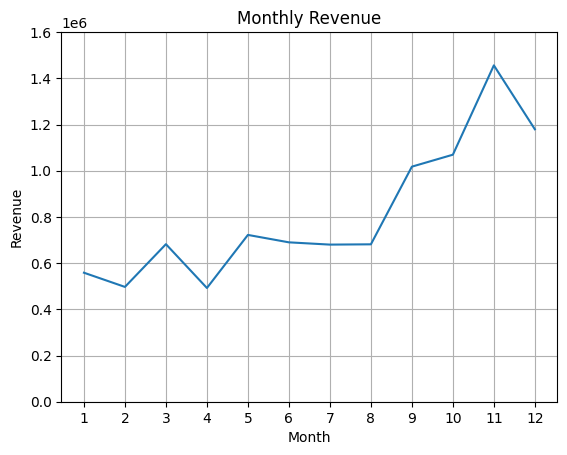

In [62]:
import matplotlib.pyplot as plt

plt.plot(monthly_revenue.index, monthly_revenue.values)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(range(1, 13))
plt.yticks(range(0, 1600001, 200000))
plt.grid(True)

plt.show()

#### Result:

Monthly revenue shows noticeable fluctuations throughout the year.

The largest increase occurs between October and November, while the largest decrease occurs between November and December. Revenue remains relatively stable between May and August, with some fluctuations.

Overall, revenue tends to increase toward the later months of the year, reaching its highest point in November.

### 7.2 Country Analysis

- Which countries generate the highest revenue?

In [63]:
df.groupby("Country")["Revenue"].sum()

Country
Australia                137009.770
Austria                   10154.320
Bahrain                     548.400
Belgium                   40910.960
Brazil                     1143.600
Canada                     3666.380
Channel Islands           20076.390
Cyprus                    12858.760
Czech Republic              707.720
Denmark                   18768.140
EIRE                     262993.380
European Community         1291.750
Finland                   22326.740
France                   197317.110
Germany                  221509.470
Greece                     4710.520
Hong Kong                  9908.240
Iceland                    4310.000
Israel                     7901.970
Italy                     16890.510
Japan                     35340.620
Lebanon                    1693.880
Lithuania                  1661.060
Malta                      2505.470
Netherlands              284661.540
Norway                    35163.460
Poland                     7213.140
Portugal            

- Which countries generate the highest revenue?

In [64]:
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending = False)
top_countries = country_revenue.head(10)
top_countries

Country
United Kingdom    8167128.184
Netherlands        284661.540
EIRE               262993.380
Germany            221509.470
France             197317.110
Australia          137009.770
Switzerland         56363.050
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Revenue, dtype: float64

- Top 10 Countries by Revenue

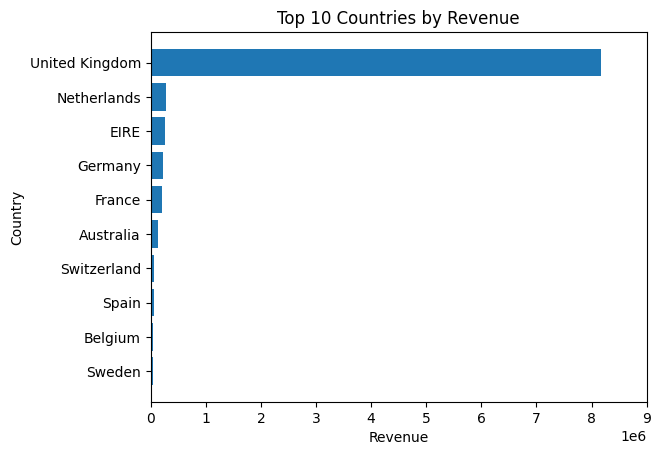

In [65]:
plt.barh(top_countries[::-1].index, top_countries[::-1].values)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")


plt.xticks(range(0, 9000001, 1000000))

plt.show()

#### Result:

The United Kingdom generates significantly more revenue than any other country in the dataset, with a large gap between the UK and the remaining top countries.

### 7.3 Product Analysis

- which Products generate the highest revenue?

In [66]:
product_revenue = df.groupby("StockCode")["Revenue"].sum().sort_values(ascending=False)
top_products = product_revenue.head(10)
top_products

StockCode
DOT       206245.48
22423     164459.49
47566      98243.88
85123A     97838.45
85099B     92175.79
23084      66661.63
POST       66230.64
22086      63715.24
84879      58792.42
79321      53746.66
Name: Revenue, dtype: float64

In [67]:
df[df["StockCode"].isin(top_products.index)][
    ["StockCode", "Description"]
].drop_duplicates()

,StockCode,Description
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER
9,84879,ASSORTED COLOUR BIRD ORNAMENT
45,POST,POSTAGE
46,22086,PAPER CHAIN KIT 50'S CHRISTMAS
177,85099B,JUMBO BAG RED RETROSPOT
178,79321,CHILLI LIGHTS
880,22423,REGENCY CAKESTAND 3 TIER
1814,DOT,DOTCOM POSTAGE
5535,47566,PARTY BUNTING
21338,22423,faulty


So DOT and POST are not real products.

In [68]:
product_revenue = (
    df[~df["StockCode"].isin(["DOT", "POST"])]
    .groupby("StockCode")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
top_products = product_revenue.head(10)
top_products

StockCode
22423     164459.49
47566      98243.88
85123A     97838.45
85099B     92175.79
23084      66661.63
22086      63715.24
84879      58792.42
79321      53746.66
22502      51023.52
22197      50967.92
Name: Revenue, dtype: float64

- Identifying the Main Description for Each Product

Some StockCodes have multiple descriptions due to damaged, faulty, or adjustment-related transactions. The most frequent description is used to represent each product.

In [69]:
description_counts = df.groupby(["StockCode", "Description"]).size()
description_counts

StockCode     Description                        
10002         INFLATABLE POLITICAL GLOBE             71
10080         GROOVY CACTUS INFLATABLE               22
              check                                   1
10120         DOGGY RUBBER                           29
10123C        HEARTS WRAPPING TAPE                    3
                                                     ..
gift_0001_20  to push order througha s stock was      1
gift_0001_30  Dotcomgiftshop Gift Voucher £30.00      7
gift_0001_40  Dotcomgiftshop Gift Voucher £40.00      3
gift_0001_50  Dotcomgiftshop Gift Voucher £50.00      4
m             Manual                                  1
Length: 4792, dtype: int64

In [70]:
max_counts = description_counts.groupby(level=0).max()

max_counts.reindex(description_counts.index, level=0)

max_counts

StockCode
10002           71
10080           22
10120           29
10123C           3
10124A           5
                ..
gift_0001_20     9
gift_0001_30     7
gift_0001_40     3
gift_0001_50     4
m                1
Length: 3958, dtype: int64

In [71]:
main_descriptions = description_counts[
    description_counts.eq(
        max_counts.reindex(description_counts.index, level=0)
    )
]

main_descriptions

StockCode     Description                       
10002         INFLATABLE POLITICAL GLOBE            71
10080         GROOVY CACTUS INFLATABLE              22
10120         DOGGY RUBBER                          29
10123C        HEARTS WRAPPING TAPE                   3
10124A        SPOTS ON RED BOOKCOVER TAPE            5
                                                    ..
gift_0001_20  Dotcomgiftshop Gift Voucher £20.00     9
gift_0001_30  Dotcomgiftshop Gift Voucher £30.00     7
gift_0001_40  Dotcomgiftshop Gift Voucher £40.00     3
gift_0001_50  Dotcomgiftshop Gift Voucher £50.00     4
m             Manual                                 1
Length: 3971, dtype: int64

- Connecting to top_products:

In [72]:
main_descriptions = main_descriptions.reset_index()

main_descriptions
    

,StockCode,Description,0
0,10002,INFLATABLE POLITICAL GLOBE,71
1,10080,GROOVY CACTUS INFLATABLE,22
2,10120,DOGGY RUBBER,29
3,10123C,HEARTS WRAPPING TAPE,3
4,10124A,SPOTS ON RED BOOKCOVER TAPE,5
...,...,...,...
3966,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,9
3967,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00,7
3968,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,3
3969,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,4


In [73]:
top_product_descriptions = main_descriptions[
    main_descriptions["StockCode"].isin(top_products.index)]

top_product_descriptions

,StockCode,Description,0
1009,22086,PAPER CHAIN KIT 50'S CHRISTMAS,1194
1112,22197,POPCORN HOLDER,861
1313,22423,REGENCY CAKESTAND 3 TIER,2189
1387,22502,PICNIC BASKET WICKER SMALL,474
1948,23084,RABBIT NIGHT LIGHT,1032
2686,47566,PARTY BUNTING,1720
2866,79321,CHILLI LIGHTS,676
3230,84879,ASSORTED COLOUR BIRD ORNAMENT,1488
3429,85099B,JUMBO BAG RED RETROSPOT,2156
3449,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2290


- SO which products generate the highest revenue?

In [74]:
top_product_data = top_product_descriptions.merge(
    top_products,
    on = "StockCode"
)
top_product_data = top_product_data.drop(columns=0)

top_product_data = top_product_data.sort_values("Revenue", ascending=False)

top_product_data

,StockCode,Description,Revenue
2,22423,REGENCY CAKESTAND 3 TIER,164459.49
5,47566,PARTY BUNTING,98243.88
9,85123A,WHITE HANGING HEART T-LIGHT HOLDER,97838.45
8,85099B,JUMBO BAG RED RETROSPOT,92175.79
4,23084,RABBIT NIGHT LIGHT,66661.63
0,22086,PAPER CHAIN KIT 50'S CHRISTMAS,63715.24
7,84879,ASSORTED COLOUR BIRD ORNAMENT,58792.42
6,79321,CHILLI LIGHTS,53746.66
3,22502,PICNIC BASKET WICKER SMALL,51023.52
1,22197,POPCORN HOLDER,50967.92


- Top 10 Products by Revenue

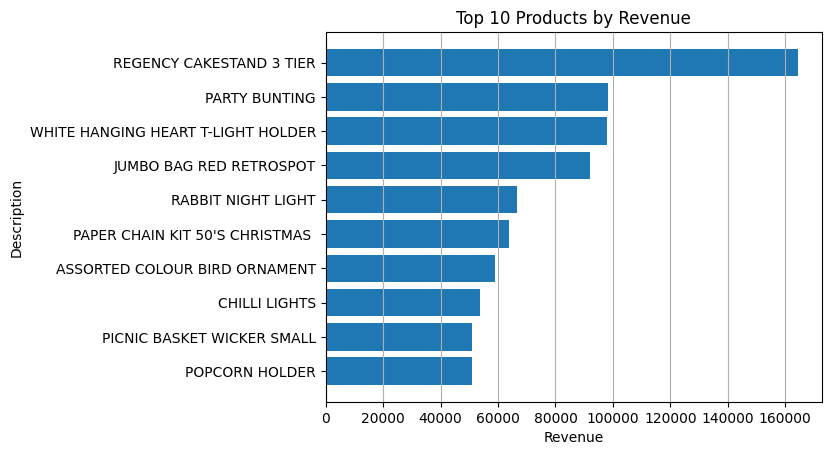

In [75]:
plt.barh(
    top_product_data[::-1]["Description"],
    top_product_data[::-1]["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Description")

plt.grid(axis="x")
plt.show()

- `REGENCY CAKESTAND 3 TIER` generates substantially more revenue than the other top products, with approximately 164K in revenue.
- The next three products generate relatively similar revenue, ranging from approximately 92K to 98K.
- Revenue contribution varies considerably even among the top 10 products, suggesting that a small number of products account for a disproportionately large share of product revenue.

### 7.4 Quantity and Revenue Relationship

- Is there a relationship between Quantity and Revenue?

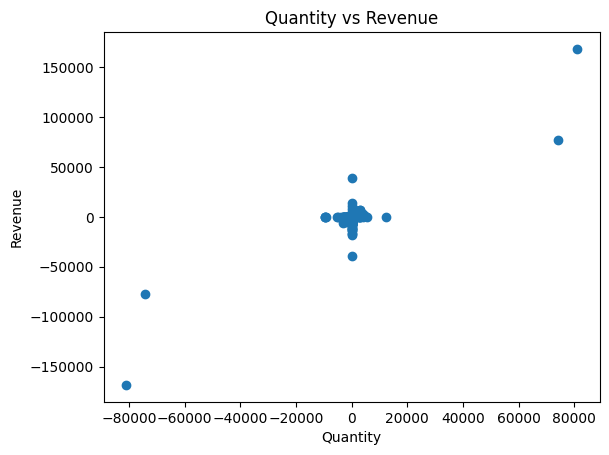

In [76]:
plt.scatter(df["Quantity"], df["Revenue"])

plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")

plt.show()

- Investigating Extreme Values

In [77]:
df["Quantity"].min()

np.int64(-80995)

In [78]:
df["Quantity"].max()

np.int64(80995)

In [79]:
df[df["Quantity"] == -80995]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,-168469.6


In [80]:
df[df["Quantity"] == 80995]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.6


In [81]:
df["Quantity"].nlargest(10)

540421    80995
61619     74215
502122    12540
74614      5568
421632     4800
206121     4300
220843     4000
97432      3906
270885     3186
52711      3114
Name: Quantity, dtype: int64

In [82]:
df["Quantity"].nsmallest(10)

540422   -80995
61624    -74215
225529    -9600
225530    -9600
4287      -9360
225528    -9058
115818    -5368
431381    -4830
341601    -3667
323458    -3167
Name: Quantity, dtype: int64

- Identifying Quantity Outliers

In [83]:
quantity_Q1 = df["Quantity"].quantile(0.25)
quantity_Q3 = df["Quantity"].quantile(0.75)

quantity_IQR = quantity_Q3 - quantity_Q1

quantity_IQR

np.float64(9.0)

The middle 50% of the Quantity data lies within a relatively narrow range, with an IQR of 9. Combined with the extreme values observed earlier, such as 80,995 and -80,995, this indicates that the Quantity distribution contains significant outliers and is strongly affected by extreme transactions.

In [84]:
quantity_lower_bound = quantity_Q1 - 1.5*quantity_IQR

quantity_lower_bound

np.float64(-12.5)

In [85]:
quantity_upper_bound = quantity_Q3 + 1.5*quantity_IQR

quantity_upper_bound

np.float64(23.5)

In [86]:
df[(df["Quantity"] > quantity_upper_bound) | (df["Quantity"] < quantity_lower_bound)].shape[0]

58501

In [87]:
df[(df["Quantity"] > quantity_upper_bound) | (df["Quantity"] < quantity_lower_bound)].shape[0] / df.shape[0] * 100

10.901328821316298

The IQR method identifies 58,501 transactions as Quantity outliers, representing approximately 10.9% of the dataset. This is a substantial proportion of the data, so these observations should not be removed automatically without further investigation.

- Analyzing Positive and Negative Quantity Outliers(to see which one is more)

In [88]:
df[(df["Quantity"] > quantity_upper_bound)].shape[0]

56525

In [89]:
df[(df["Quantity"] < quantity_lower_bound)].shape[0]

1976

The majority of Quantity outliers are positive values, with 56,525 positive outliers compared with 1,976 negative outliers. This indicates that most extreme Quantity values are associated with unusually large positive quantities rather than cancellations.

- Quantity vs Revenue Without Outliers

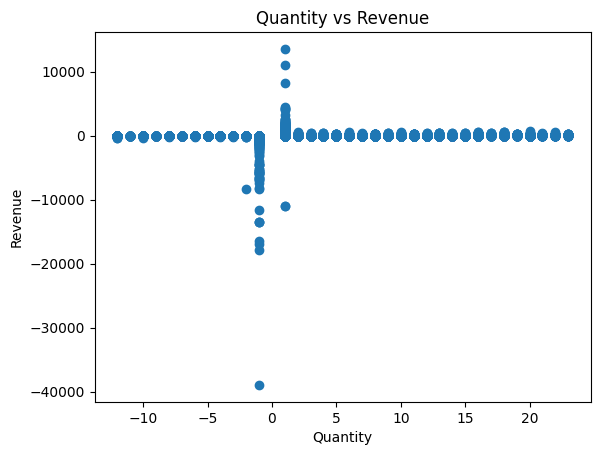

In [90]:
plt.scatter(df[(df["Quantity"] < quantity_upper_bound) & (df["Quantity"] > quantity_lower_bound)]["Quantity"],
            df[(df["Quantity"] < quantity_upper_bound) & (df["Quantity"] > quantity_lower_bound)]["Revenue"])

plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")

plt.show()

- Measuring the Correlation Between Quantity and Revenue

In [91]:
df[["Quantity", "Revenue"]].corr()

,Quantity,Revenue
Quantity,1.000000,0.886712
Revenue,0.886712,1.000000


In [92]:
df[(df["Quantity"] < quantity_upper_bound) & (df["Quantity"] > quantity_lower_bound)][["Quantity", "Revenue"]].corr()

,Quantity,Revenue
Quantity,1.000000,0.075497
Revenue,0.075497,1.000000


The correlation between Quantity and Revenue is 0.887 when all transactions are included. However, after removing Quantity outliers using the IQR method, the correlation drops substantially to 0.075.

This indicates that the strong correlation in the full dataset is largely influenced by extreme transactions. Among the remaining observations, there is only a very weak linear relationship between Quantity and Revenue.

### 7.5 UnitPrice and Revenue Relationship

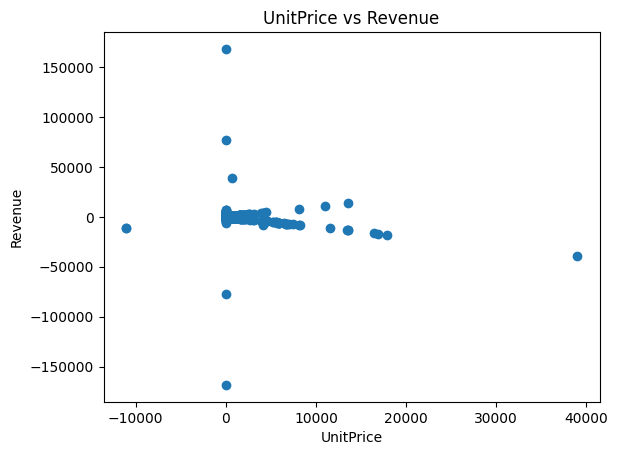

In [93]:
plt.scatter(df["UnitPrice"], df["Revenue"])

plt.title("UnitPrice vs Revenue")
plt.xlabel("UnitPrice")
plt.ylabel("Revenue")

plt.show()

- Investigating Extreme UnitPrice Values

In [94]:
df["UnitPrice"].min()

np.float64(-11062.06)

In [95]:
df["UnitPrice"].max()

np.float64(38970.0)

In [96]:
df[df["UnitPrice"] == -11062.06]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,-11062.06
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,-11062.06


In [97]:
df[df["UnitPrice"] == 38970]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.0,15098.0,United Kingdom,-38970.0


In [98]:
unitprice_Q1 = df["UnitPrice"].quantile(0.25)
unitprice_Q3 = df["UnitPrice"].quantile(0.75)

unitprice_IQR = unitprice_Q3 - unitprice_Q1

unitprice_IQR

np.float64(2.88)

In [99]:
unitprice_lower_bound = unitprice_Q1 - 1.5 * unitprice_IQR

unitprice_lower_bound

np.float64(-3.0700000000000003)

In [100]:
unitprice_upper_bound = unitprice_Q3 + 1.5 * unitprice_IQR

unitprice_upper_bound

np.float64(8.45)

- Identifying UnitPrice Outliers Using the IQR Method

In [101]:
df[(df["UnitPrice"] < unitprice_lower_bound) |
   (df["UnitPrice"] > unitprice_upper_bound)].shape[0]

39450

In [102]:
df[(df["UnitPrice"] < unitprice_lower_bound) |
   (df["UnitPrice"] > unitprice_upper_bound)].shape[0] / df.shape[0] * 100

7.351283260131075

The IQR method identifies 39,450 transactions as UnitPrice outliers, representing approximately 7.35% of the dataset. Although this is a smaller proportion than the Quantity outliers, it is still a substantial number of observations and should not be removed automatically.

- Analyzing Positive and Negative UnitPrice Outliers

In [103]:
df[(df["UnitPrice"] < unitprice_lower_bound)].shape[0]

2

In [104]:
df[(df["UnitPrice"] > unitprice_upper_bound)].shape[0]

39448

The UnitPrice outliers are almost entirely positive values, with 39,448 positive outliers and only 2 negative outliers. This indicates that the main source of extreme UnitPrice values is unusually high prices rather than negative prices.

- UnitPrice vs Revenue Without Outliers

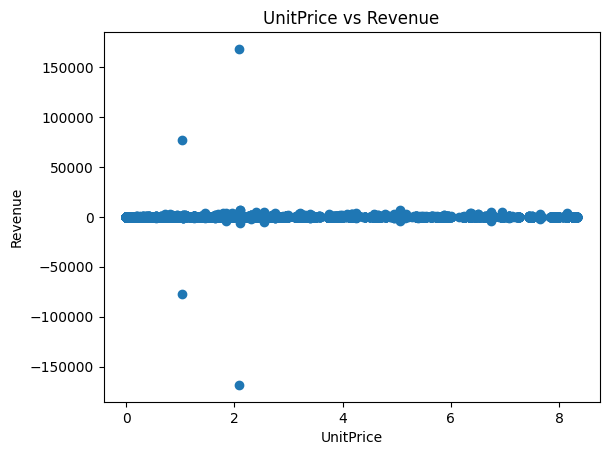

In [105]:
plt.scatter(df[(df["UnitPrice"] > unitprice_lower_bound) & (df["UnitPrice"] < unitprice_upper_bound)]["UnitPrice"],
            df[(df["UnitPrice"] > unitprice_lower_bound) & (df["UnitPrice"] < unitprice_upper_bound)]["Revenue"])

plt.title("UnitPrice vs Revenue")
plt.xlabel("UnitPrice")
plt.ylabel("Revenue")

plt.show()

- Measuring the Correlation Between UnitPrice and Revenue

In [106]:
df[["UnitPrice", "Revenue"]].corr()

,UnitPrice,Revenue
UnitPrice,1.000000,-0.162043
Revenue,-0.162043,1.000000


In [107]:
df[(df["UnitPrice"] > unitprice_lower_bound) & 
   (df["UnitPrice"] < unitprice_upper_bound)][["UnitPrice", "Revenue"]].corr()

,UnitPrice,Revenue
UnitPrice,1.000000,0.009536
Revenue,0.009536,1.000000


The correlation between UnitPrice and Revenue is -0.162 when all transactions are included. After removing UnitPrice outliers using the IQR method, the correlation drops to 0.010.

This suggests that extreme UnitPrice transactions were influencing the overall correlation. After removing these outliers, there is almost no linear relationship between UnitPrice and Revenue in the remaining transactions.

### 7.6 Customer Analysis

- which customers generate the most revenue?
- Top 10 Customers by Revenue

In [108]:
customer_revenue = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
top_customer_revenue = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)

top_customer_revenue

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: Revenue, dtype: float64

Text(0, 0.5, 'CustomerID')

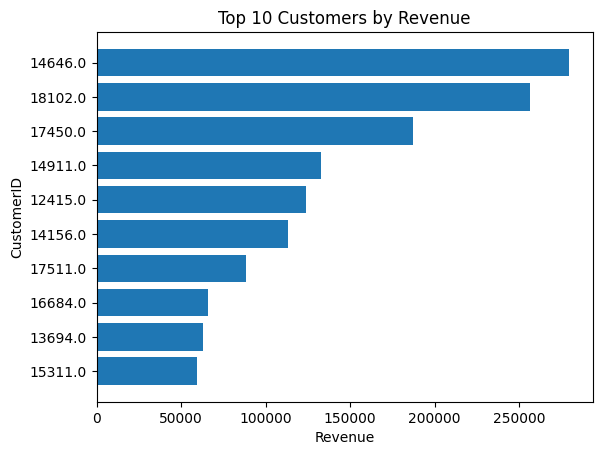

In [109]:
plt.barh(top_customer_revenue[::-1].index.values.astype(str), top_customer_revenue[::-1].values)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("CustomerID")

- Customer Purchase Frequency

- Which customers make the most transactions?

In [110]:
customer_transactions = df.groupby("CustomerID").size().sort_values(ascending= False)
top_customer_transactions = df.groupby("CustomerID").size().sort_values(ascending= False).head(10)

top_customer_transactions

CustomerID
17841.0    7812
14911.0    5898
14096.0    5128
12748.0    4459
14606.0    2759
15311.0    2478
14646.0    2085
13089.0    1853
13263.0    1667
14298.0    1640
dtype: int64

- Customer Revenue vs Purchase Frequency

In [111]:
customer_revenue_df = customer_revenue.to_frame(name="Revenue")

customer_transactions_df = customer_transactions.to_frame(name="TransactionCount")

customer_analysis = customer_revenue_df.merge(
    customer_transactions_df,
    on="CustomerID"
)

customer_analysis

,Revenue,TransactionCount
CustomerID,,
14646.0,279489.02,2085
18102.0,256438.49,433
17450.0,187322.17,350
14911.0,132458.73,5898
12415.0,123725.45,778
...,...,...
12503.0,-1126.00,1
17603.0,-1165.30,15
14213.0,-1192.20,5


- Customer Purchase Frequency vs Revenue

<function matplotlib.pyplot.show(close=None, block=None)>

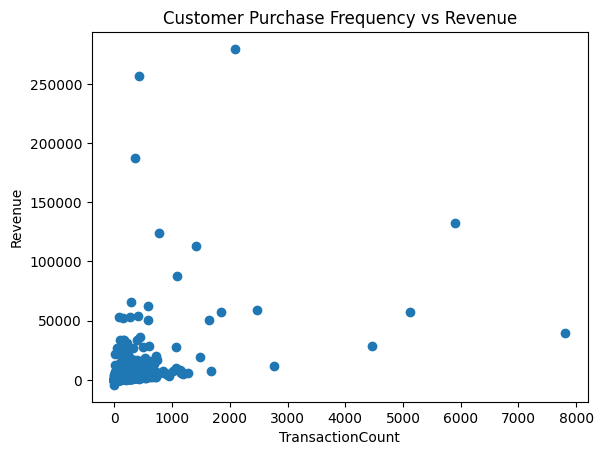

In [112]:
plt.scatter(customer_analysis["TransactionCount"], customer_analysis["Revenue"])

plt.title("Customer Purchase Frequency vs Revenue")
plt.xlabel("TransactionCount")
plt.ylabel("Revenue")

plt.show

- Customer Purchase Frequency and Revenue Correlation

In [113]:
customer_analysis[["TransactionCount", "Revenue"]].corr()

,TransactionCount,Revenue
TransactionCount,1.000000,0.449659
Revenue,0.449659,1.000000


The correlation between customer purchase frequency and Revenue is 0.45, indicating a moderate positive linear relationship. Customers with more transactions tend to generate higher revenue, but transaction frequency alone does not fully explain customer revenue.

- Average Revenue per Customer Transaction

In [114]:
customer_analysis["AvgRevenuePerTransaction"] = (
    customer_analysis["Revenue"] / customer_analysis["TransactionCount"]
)
customer_analysis

,Revenue,TransactionCount,AvgRevenuePerTransaction
CustomerID,,,
14646.0,279489.02,2085,134.047492
18102.0,256438.49,433,592.236697
17450.0,187322.17,350,535.206200
14911.0,132458.73,5898,22.458245
12415.0,123725.45,778,159.030141
...,...,...,...
12503.0,-1126.00,1,-1126.000000
17603.0,-1165.30,15,-77.686667
14213.0,-1192.20,5,-238.440000


- Top Customers by Average Revenue per Transaction

In [116]:
customer_analysis.sort_values(by="AvgRevenuePerTransaction", ascending=False).head(10)

,Revenue,TransactionCount,AvgRevenuePerTransaction
CustomerID,,,
15195.0,3861.00,1,3861.000000
13135.0,3096.00,1,3096.000000
17846.0,2033.10,1,2033.100000
16532.0,6748.80,4,1687.200000
15749.0,21535.90,15,1435.726667
16000.0,12393.70,9,1377.077778
16754.0,2002.40,2,1001.200000
12798.0,6977.04,8,872.130000
17553.0,1487.60,2,743.800000


- Average Revenue per Transaction for Frequent Customers

In [118]:
customer_analysis[customer_analysis["TransactionCount"] >= 10
                  ].sort_values(by="AvgRevenuePerTransaction", ascending=False).head(10)

,Revenue,TransactionCount,AvgRevenuePerTransaction
CustomerID,,,
15749.0,21535.90,15,1435.726667
17949.0,52750.84,79,667.732152
18102.0,256438.49,433,592.236697
16333.0,26626.80,45,591.706667
17450.0,187322.17,350,535.206200
17857.0,26763.34,56,477.916786
12557.0,11990.96,33,363.362424
15769.0,51823.72,147,352.542313
12931.0,33462.81,102,328.066765


#### Insight
Among customers with at least 10 transactions, customer 15749 has the highest average revenue per transaction. This shows that high customer value can come from larger individual transactions, not only from frequent purchases. Customer 18102 is particularly valuable because it combines a high average transaction value with a large number of transactions, resulting in very high total revenue.